In [92]:
import numpy as np
import scipy.linalg
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
np.set_printoptions(precision=3)
from qutip import Qobj 

In [93]:
N = 50  #N is taken to be odd for simplicity
J = N/2
Omega = 1
Gamma = 0.1
m = np.arange(-J, J+1, 1,)
dim = len(m)

Id = sp.eye(dim, format='csr')

def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

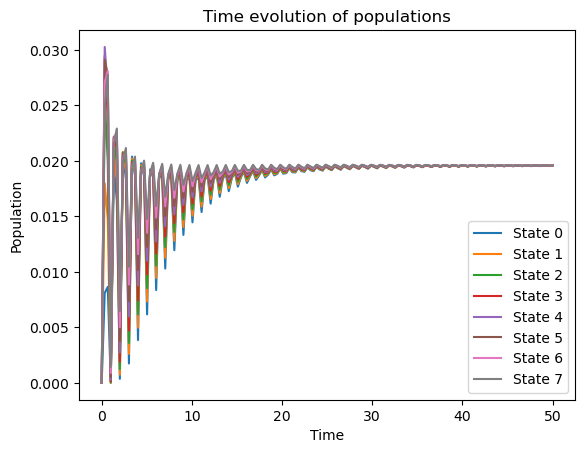

In [94]:
J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L1 = -1j * Omega * N * flatten_left(J_x)
L2 = 1j * Omega * N * flatten_right(J_x)
L3 = Gamma * flatten_both(J_min, J_pl)
L4 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
Liou = L1 + L2 + L3 + L4 + L5

psi0 = np.zeros(dim, dtype=complex)
psi0[int(dim/2)] = 1
rho0 = np.kron(psi0, psi0.conj())

def rhs(t, rho):
    return Liou @ rho

tsteps = 150
t_span = np.linspace(0, 50, tsteps)  
sol = solve_ivp(rhs, (t_span[0], t_span[-1]), rho0, t_eval=t_span) 
rho_t = sol.y

psteady_m = np.zeros(dim, dtype=complex)
for i in range(dim):
    psteady_m[i] = np.abs(rho_t[i*dim + i, -1])

for i in range(min(8, dim)):  # Plot first 4 diagonal elements
    plt.plot(t_span, np.real(rho_t[i*dim + i, :]), label=f'State {i}')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Time evolution of populations')
plt.legend()
plt.show()

# Exercise b)

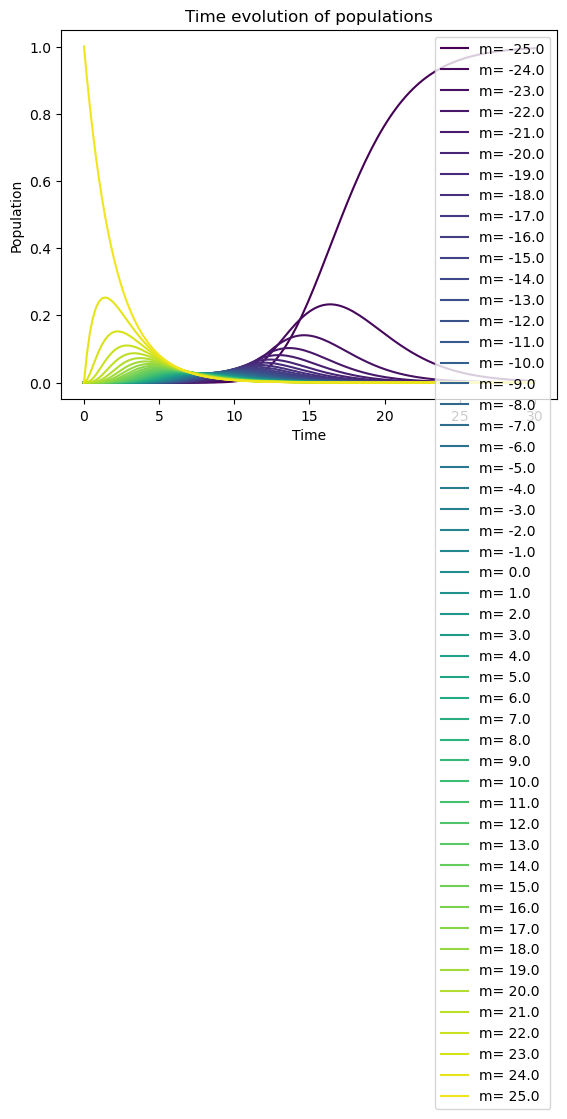

In [95]:

N = 50 #N is taken to be odd for simplicity
J = N/2
Omega = 0
Gamma = 0.01
m = np.arange(-J, J+1, 1,)
dim = len(m)

Id = sp.eye(dim, format='csr')

def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L1 = -1j * Omega * N * flatten_left(J_x)
L2 = 1j * Omega * N * flatten_right(J_x)
L3 = Gamma * flatten_both(J_min, J_pl)
L4 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
Liou = L1 + L2 + L3 + L4 + L5

psi0 = np.zeros(dim, dtype=complex)
psi0[50] = 1
rho0 = np.kron(psi0, psi0.conj())

def rhs(t, rho):
    return Liou @ rho

tsteps = 150
t_span = np.linspace(0, 30, tsteps)  
sol = solve_ivp(rhs, (t_span[0], t_span[-1]), rho0, t_eval=t_span) 
rho_t = sol.y

#psteady_m = np.zeros(dim, dtype=complex)
#for i in range(dim):
    #psteady_m[i] = np.abs(rho_t[i*dim + i, -1])

for i in range(min(70, dim)):  # Plot first diagonal elements
    plt.plot(t_span, np.real(rho_t[i*dim + i, :]), label=f'm= {m[i]}', color=plt.cm.viridis(i / dim))
#plt.plot(t_span, np.real(rho_t[-1, :]), label=f'State {50}', color='black')
    
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Time evolution of populations')
plt.legend()
plt.show()

/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


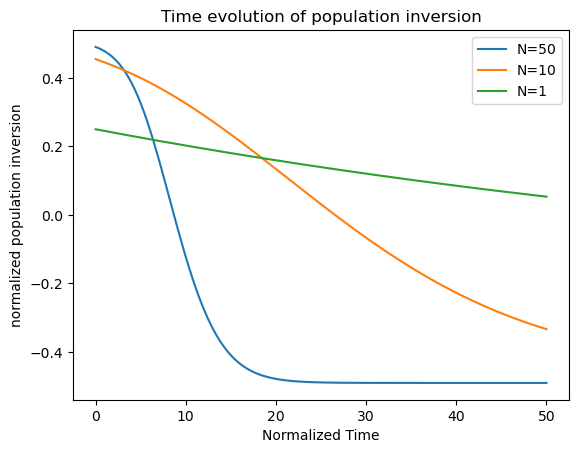

In [96]:
tsteps = 150
t_span = np.linspace(0, 50/(Gamma*N), tsteps)  
tau50 = t_span * Gamma * N

sol = solve_ivp(rhs, (tau50[0], tau50[-1]), rho0, t_eval=tau50) 
rho_t50 = sol.y
J = 0
for i in range(dim):
    J = J  + rho_t50[i*dim + i, :]* m[i]
J = J/dim

plt.plot(tau50, J , label=f'N=50')
plt.xlabel('Time')
plt.ylabel('normalized population inversion')
plt.title('Time evolution of population inversion')
plt.legend()
#plt.show()

N = 10 #N is taken to be odd for simplicity
J = N/2
Omega = 0
Gamma = 0.01
m = np.arange(-J, J+1, 1,)
dim = len(m)

Id = sp.eye(dim, format='csr')

def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L1_10 = -1j * Omega * N * flatten_left(J_x)
L2_10 = 1j * Omega * N * flatten_right(J_x)
L3_10 = Gamma * flatten_both(J_min, J_pl)
L4_10 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5_10 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
Liou10 = L1_10 + L2_10 + L3_10 + L4_10 + L5_10

psi0 = np.zeros(dim, dtype=complex)
psi0[10] = 1
rho0 = np.kron(psi0, psi0.conj())

def rhs10(t, rho):
    return Liou10 @ rho

tsteps = 150
t_span = np.linspace(0, 50/(Gamma*N), tsteps)  
tau10 = t_span * Gamma * N

sol = solve_ivp(rhs10, (tau10[0], tau10[-1]), rho0, t_eval=tau10) 
rho_t10 = sol.y
#tau = t_span * Gamma * N
J = 0
for i in range(dim):
    J = J  + rho_t10[i*dim + i, :]* m[i]
J = J/dim

plt.plot(tau10, J , label=f'N=10')
plt.xlabel('Time')
plt.ylabel('normalized population inversion')
plt.title('Time evolution of population inversion')
plt.legend()


N = 1 #N is taken to be odd for simplicity
J = N/2
Omega = 0
Gamma = 0.01
m = np.arange(-J, J+1, 1,)
dim = len(m)

Id = sp.eye(dim, format='csr')

def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L1_1 = -1j * Omega * N * flatten_left(J_x)
L2_1 = 1j * Omega * N * flatten_right(J_x)
L3_1 = Gamma * flatten_both(J_min, J_pl)
L4_1 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5_1 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
Liou1 = L1_1 + L2_1 + L3_1 + L4_1 + L5_1

psi0 = np.zeros(dim, dtype=complex)
psi0[1] = 1
rho0 = np.kron(psi0, psi0.conj())

def rhs1(t, rho):
    return Liou1 @ rho

tsteps = 150

t_span = np.linspace(0, 50/(Gamma*N), tsteps)  
tau1 = t_span * Gamma * N
sol = solve_ivp(rhs1, (tau1[0], tau1[-1]), rho0, t_eval=tau1) 
rho_t1 = sol.y

J = 0
for i in range(dim):
    J = J  + rho_t1[i*dim + i, :]* m[i]
J = J/dim



plt.plot(tau1, J , label=f'N=1')
plt.xlabel('Normalized Time')
plt.ylabel('normalized population inversion')
plt.title('Time evolution of population inversion')
plt.legend()



emitted photon current:


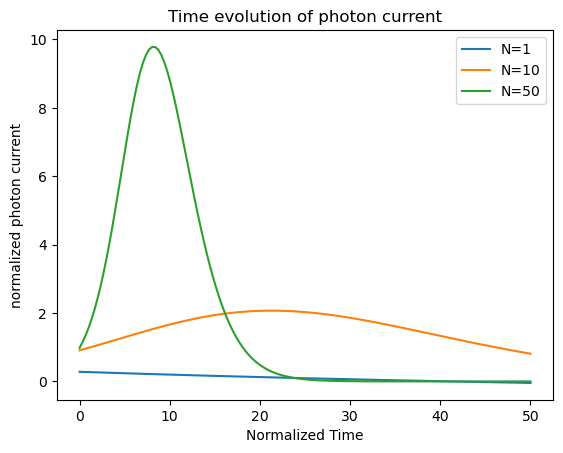

In [97]:
I_ph1 = 0 
for i in range(dim):
    I_ph1 += rho_t1[i*dim + i, :] * (J-m[i]+1)*(J+m[i])
I_ph1 = I_ph1 / dim

J = 5
m10 = np.arange(-J, J+1, 1,)
dim10 = len(m10)
I_ph10 = 0 
for i in range(dim10):
    I_ph10 += rho_t10[i*dim10 + i, :] * (J-m10[i]+1)*(J+m10[i])
I_ph10 = I_ph10 / dim10

J = 25
m25 = np.arange(-J, J+1, 1,)
dim25 = len(m25)
I_ph25 = 0 
for i in range(dim25):
    I_ph25 += rho_t50[i*dim25 + i, :] * (J-m25[i]+1)*(J+m25[i])
I_ph25 = I_ph25 / dim25
plt.figure()
plt.plot(tau1, I_ph1 , label=f'N=1')
plt.plot(tau10, I_ph10 , label=f'N=10')
plt.plot(tau50, I_ph25 , label=f'N=50')
plt.xlabel('Normalized Time')
plt.ylabel('normalized photon current')
plt.title('Time evolution of photon current')
plt.legend()
plt.show()

# c)

5.0


/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/Qutip_E/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


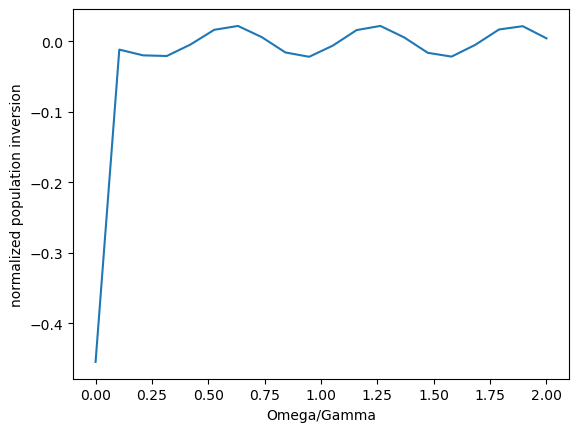

In [138]:

N = 10 #N is taken to be odd for simplicity
J = N/2
J_vals = []
m = np.arange(-J, J+1, 1,)
dim = len(m)
Gamma = 0.02

Id = sp.eye(dim, format='csr')
def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L3_10 = Gamma * flatten_both(J_min, J_pl)
L4_10 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5_10 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
psi0 = np.zeros(dim, dtype=complex)
psi0[10] = 1
rho0 = np.kron(psi0, psi0.conj())
tsteps = 100
t_span = np.linspace(0, 200, tsteps)  

for i in np.arange(0, 2, 0.1):
    Omega = i   
    m = np.arange(-J, J+1, 1,)
    dim = len(m)

    L1_10 = -1j * Omega * N * flatten_left(J_x)
    L2_10 = 1j * Omega * N * flatten_right(J_x)
    
    Liou10 = L1_10 + L2_10 + L3_10 + L4_10 + L5_10



    def rhs10(t, rho):
        return Liou10 @ rho

  
#tau10 = t_span * Gamma * N

    sol = solve_ivp(rhs10, (t_span[0], t_span[-1]), rho0, t_eval=t_span) 
    rho_t10 = sol.y
#tau = t_span * Gamma * N
    Jott = 0
    for i in range(dim):
        Jott = Jott  + rho_t10[i*dim + i, 99]* m[i]
    Jott = Jott/dim
    J_vals.append(Jott)



x_vals = np.linspace(0, 2, len(J_vals))
plt.plot(x_vals, J_vals , label=f'N=10')
plt.xlabel('Omega/Gamma')
plt.ylabel('normalized population inversion')
print(J)
#plt.plot(tau10, J , label=f'N=10')
#plt.xlabel('Time')
#plt.ylabel('normalized population inversion')
#plt.title('Time evolution of population inversion')
#plt.legend()



0.5


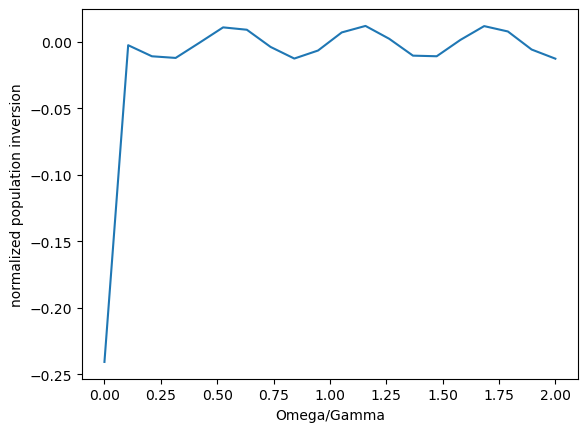

In [140]:

N = 1 #N is taken to be odd for simplicity
J = N/2
J_vals = []
m = np.arange(-J, J+1, 1,)
dim = len(m)
Gamma = 0.02

Id = sp.eye(dim, format='csr')
def flatten_left(operator):
    return sp.kron(operator, Id, format='csr')

def flatten_right(operator):
    return sp.kron(Id, operator.T, format='csr')

def flatten_both(operatorA, operatorB):
    return sp.kron(operatorA, operatorB.T, format='csr')

J_pl = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim-1):
    J_pl[i+1, i] = np.sqrt((J - m[i]) * (J + m[i] + 1))
J_pl = J_pl.tocsr()

J_min = sp.lil_matrix((dim, dim), dtype=complex)
for i in range(dim):
    J_min[i-1, i] = np.sqrt((J + m[i]) * (J - m[i] + 1))
J_min = J_min.tocsr()

J_x = 0.5 * (J_pl + J_min)

L3_10 = Gamma * flatten_both(J_min, J_pl)
L4_10 = -0.5 * Gamma * flatten_left(J_pl @ J_min)
L5_10 = -0.5 * Gamma * flatten_right(J_pl @ J_min)
psi0 = np.zeros(dim, dtype=complex)
psi0[1] = 1
rho0 = np.kron(psi0, psi0.conj())
tsteps = 100
t_span = np.linspace(0, 200, tsteps)  

for i in np.arange(0, 2, 0.1):
    Omega = i   
    m = np.arange(-J, J+1, 1,)
    dim = len(m)

    L1_10 = -1j * Omega * N * flatten_left(J_x)
    L2_10 = 1j * Omega * N * flatten_right(J_x)
    
    Liou10 = L1_10 + L2_10 + L3_10 + L4_10 + L5_10



    def rhs10(t, rho):
        return Liou10 @ rho

  
#tau10 = t_span * Gamma * N

    sol = solve_ivp(rhs10, (t_span[0], t_span[-1]), rho0, t_eval=t_span) 
    rho_t10 = sol.y
#tau = t_span * Gamma * N
    Jott = 0
    for i in range(dim):
        Jott = Jott  + rho_t10[i*dim + i, 99]* m[i]
    Jott = Jott/dim
    J_vals.append(Jott)



x_vals = np.linspace(0, 2, len(J_vals))
plt.plot(x_vals, J_vals , label=f'N=1')
plt.xlabel('Omega/Gamma')
plt.ylabel('normalized population inversion')
print(J)